In [14]:
# Final forecasting insights

print("Forecasting Completed Successfully")
print("=" * 50)

print("Historical data range:", forecast_df["date"].min(), "to", forecast_df["date"].max())
print("Forecast start date:", future_df["date"].min())
print("Forecast end date:", future_df["date"].max())

print("\nLatest historical average price:")
print(round(forecast_df.iloc[-1]["average_price"], 2), "AED")

print("\nForecasted average price after 12 months:")
print(round(future_df.iloc[-1]["forecast_average_price"], 2), "AED")

price_change = future_df.iloc[-1]["forecast_average_price"] - forecast_df.iloc[-1]["average_price"]
price_change_pct = (price_change / forecast_df.iloc[-1]["average_price"]) * 100

print("\nExpected 12-month change:")
print(round(price_change, 2), "AED")
print(round(price_change_pct, 2), "%")

Forecasting Completed Successfully
Historical data range: 2010-01-01 00:00:00 to 2023-03-01 00:00:00
Forecast start date: 2023-04-01 00:00:00
Forecast end date: 2024-03-01 00:00:00

Latest historical average price:
2478863.12 AED

Forecasted average price after 12 months:
3038452.86 AED

Expected 12-month change:
559589.73 AED
22.57 %


In [13]:
# Save forecast model summary

forecast_model_summary = {
    "model_name": "Linear Regression Trend Forecast",
    "target": "monthly_average_transaction_price",
    "training_start_date": train_df["date"].min(),
    "training_end_date": train_df["date"].max(),
    "test_start_date": test_df["date"].min(),
    "test_end_date": test_df["date"].max(),
    "mae": mae,
    "rmse": rmse,
    "r2": r2,
    "forecast_period_months": 12
}

forecast_model_summary_df = pd.DataFrame([forecast_model_summary])

forecast_summary_path = PROCESSED_DATA_DIR / "forecast_model_summary.csv"
forecast_model_summary_df.to_csv(forecast_summary_path, index=False)

forecast_model_summary_df

,model_name,target,training_start_date,training_end_date,test_start_date,test_end_date,mae,rmse,r2,forecast_period_months
0,Linear Regression Trend Forecast,monthly_average_transaction_price,2010-01-01,2020-07-01,2020-08-01,2023-03-01,"355,268.01","402,073.30",-2.06,12


In [12]:
# Save next 12 months forecast

future_forecast_path = PROCESSED_DATA_DIR / "forecast_next_12_months_average_price.csv"
future_df.to_csv(future_forecast_path, index=False)

print("Next 12 months forecast saved to:", future_forecast_path)

future_df

Next 12 months forecast saved to: c:\Projects\dubai-real-estate-price-intelligence-dashboard\data\processed\forecast_next_12_months_average_price.csv


,date,time_index,forecast_average_price
0,2023-04-01,159,"2,977,872.10"
1,2023-05-01,160,"2,983,379.45"
2,2023-06-01,161,"2,988,886.79"
3,2023-07-01,162,"2,994,394.13"
4,2023-08-01,163,"2,999,901.47"
5,2023-09-01,164,"3,005,408.81"
6,2023-10-01,165,"3,010,916.15"
7,2023-11-01,166,"3,016,423.49"
8,2023-12-01,167,"3,021,930.83"
9,2024-01-01,168,"3,027,438.18"


In [11]:
# Save monthly forecasting dataset

monthly_forecast_path = PROCESSED_DATA_DIR / "forecast_monthly_market_data.csv"
forecast_df.to_csv(monthly_forecast_path, index=False)

print("Monthly forecasting dataset saved to:", monthly_forecast_path)

Monthly forecasting dataset saved to: c:\Projects\dubai-real-estate-price-intelligence-dashboard\data\processed\forecast_monthly_market_data.csv


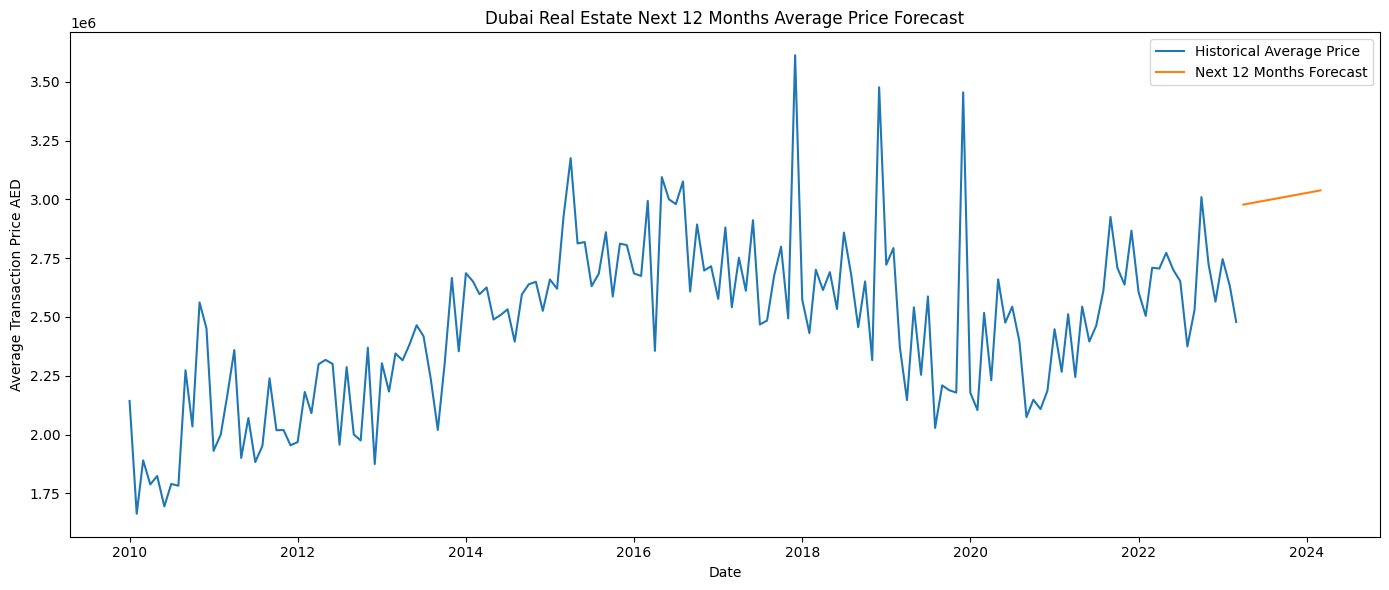

In [10]:
# Plot historical average price and next 12 months forecast

plt.figure(figsize=(14, 6))

plt.plot(forecast_df["date"], forecast_df["average_price"], label="Historical Average Price")
plt.plot(future_df["date"], future_df["forecast_average_price"], label="Next 12 Months Forecast")

plt.title("Dubai Real Estate Next 12 Months Average Price Forecast")
plt.xlabel("Date")
plt.ylabel("Average Transaction Price AED")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "next_12_months_average_price_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# Forecast next 12 months

last_date = forecast_df["date"].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="MS")

future_time_index = np.arange(
    forecast_df["time_index"].max() + 1,
    forecast_df["time_index"].max() + 13
)

future_df = pd.DataFrame({
    "date": future_dates,
    "time_index": future_time_index
})

future_df["forecast_average_price"] = price_forecast_model.predict(future_df[["time_index"]])

future_df

,date,time_index,forecast_average_price
0,2023-04-01,159,"2,977,872.10"
1,2023-05-01,160,"2,983,379.45"
2,2023-06-01,161,"2,988,886.79"
3,2023-07-01,162,"2,994,394.13"
4,2023-08-01,163,"2,999,901.47"
5,2023-09-01,164,"3,005,408.81"
6,2023-10-01,165,"3,010,916.15"
7,2023-11-01,166,"3,016,423.49"
8,2023-12-01,167,"3,021,930.83"
9,2024-01-01,168,"3,027,438.18"


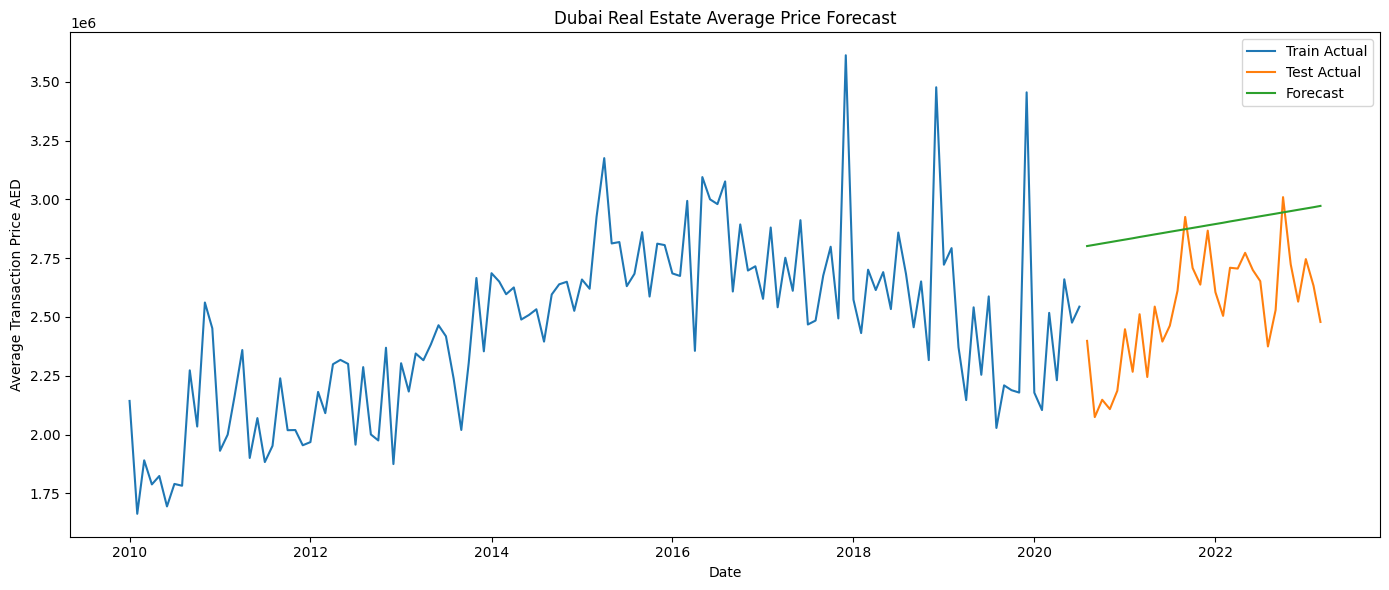

In [8]:
# Plot actual vs forecast average price

plt.figure(figsize=(14, 6))

plt.plot(train_df["date"], train_df["average_price"], label="Train Actual")
plt.plot(test_df["date"], test_df["average_price"], label="Test Actual")
plt.plot(test_df["date"], test_df["predicted_average_price"], label="Forecast")

plt.title("Dubai Real Estate Average Price Forecast")
plt.xlabel("Date")
plt.ylabel("Average Transaction Price AED")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "average_price_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Forecast average property price using Linear Regression trend model

X_train = train_df[["time_index"]]
y_train = train_df["average_price"]

X_test = test_df[["time_index"]]
y_test = test_df["average_price"]

price_forecast_model = LinearRegression()
price_forecast_model.fit(X_train, y_train)

test_df["predicted_average_price"] = price_forecast_model.predict(X_test)

mae = mean_absolute_error(y_test, test_df["predicted_average_price"])
rmse = np.sqrt(mean_squared_error(y_test, test_df["predicted_average_price"]))
r2 = r2_score(y_test, test_df["predicted_average_price"])

print("Average Price Forecast Model")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

Average Price Forecast Model
MAE: 355268.01
RMSE: 402073.3
R2: -2.0605


In [6]:
# Train/test split based on time order

train_size = int(len(forecast_df) * 0.8)

train_df = forecast_df.iloc[:train_size].copy()
test_df = forecast_df.iloc[train_size:].copy()

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train date range: 2010-01-01 00:00:00 to 2020-07-01 00:00:00
Test date range: 2020-08-01 00:00:00 to 2023-03-01 00:00:00
Train shape: (127, 8)
Test shape: (32, 8)


In [5]:
# Create time index for forecasting

forecast_df["time_index"] = np.arange(len(forecast_df))

forecast_df[["date", "time_index", "average_price", "total_transactions"]].head()

,date,time_index,average_price,total_transactions
0,2010-01-01,0,"2,142,882.35",3789
1,2010-02-01,1,"1,662,890.97",5518
2,2010-03-01,2,"1,890,310.57",11258
3,2010-04-01,3,"1,787,882.36",4676
4,2010-05-01,4,"1,823,623.50",5142


In [4]:
# Filter recent reliable period for forecasting
# Older data from 1990s may not represent current Dubai market behavior

forecast_df = monthly_forecast_df[monthly_forecast_df["date"] >= "2010-01-01"].copy()

forecast_df = forecast_df.reset_index(drop=True)

print("Forecasting dataset shape:", forecast_df.shape)
print("Date range:", forecast_df["date"].min(), "to", forecast_df["date"].max())

forecast_df.head()

Forecasting dataset shape: (159, 7)
Date range: 2010-01-01 00:00:00 to 2023-03-01 00:00:00


,transaction_year_month,total_transactions,total_sales_value,average_price,median_price,average_price_per_sqm,date
0,2010-01,3789,"8,119,381,223.00","2,142,882.35","1,120,000.00","11,399.47",2010-01-01
1,2010-02,5518,"9,175,832,383.00","1,662,890.97","960,488.00","9,603.93",2010-02-01
2,2010-03,11258,"21,281,116,364.00","1,890,310.57","1,017,839.00","12,515.10",2010-03-01
3,2010-04,4676,"8,360,137,892.00","1,787,882.36","898,014.00","9,924.89",2010-04-01
4,2010-05,5142,"9,377,072,045.00","1,823,623.50","1,093,696.00","9,716.69",2010-05-01


In [3]:
# Create monthly forecasting dataset

monthly_forecast_df = (
    df.groupby("transaction_year_month")
    .agg(
        total_transactions=("transaction_id", "count"),
        total_sales_value=("actual_worth", "sum"),
        average_price=("actual_worth", "mean"),
        median_price=("actual_worth", "median"),
        average_price_per_sqm=("meter_sale_price", "mean")
    )
    .reset_index()
)

monthly_forecast_df["date"] = pd.to_datetime(monthly_forecast_df["transaction_year_month"] + "-01")

monthly_forecast_df = monthly_forecast_df.sort_values("date").reset_index(drop=True)

monthly_forecast_df.head()

,transaction_year_month,total_transactions,total_sales_value,average_price,median_price,average_price_per_sqm,date
0,1995-03,1,"300,000.00","300,000.00","300,000.00",215.28,1995-03-01
1,1995-10,2,"1,000,000.00","500,000.00","500,000.00",403.65,1995-10-01
2,1996-01,1,"500,000.00","500,000.00","500,000.00",359.71,1996-01-01
3,1996-02,1,"500,000.00","500,000.00","500,000.00",358.80,1996-02-01
4,1997-11,20,"43,541,480.00","2,177,074.00","1,085,000.00","5,907.96",1997-11-01


In [2]:
# Load cleaned dataset

file_path = PROCESSED_DATA_DIR / "dubai_real_estate_transactions_cleaned.csv"

df = pd.read_csv(file_path, low_memory=False)

df["instance_date"] = pd.to_datetime(df["instance_date"], errors="coerce")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (1044151, 27)


,transaction_id,procedure_id,trans_group_en,procedure_name_en,instance_date,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_id,area_name_en,building_name_en,project_name_en,master_project_en,nearest_metro_en,nearest_mall_en,nearest_landmark_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,meter_rent_price,transaction_year,transaction_month,transaction_quarter,transaction_year_month
0,1-11-2001-165,11,Sales,Sell,2001-02-24,Land,Unknown,Commercial,Existing Properties,364,Al Wasl,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,"1,393.55","1,350,000.00",968.75,NaN,"2,001.00",2.00,1.00,2001-02
1,3-9-2004-223,9,Gifts,Grant,2004-12-13,Villa,Unknown,Commercial,Existing Properties,365,Al Hudaiba,Unknown,Unknown,Unknown,Al Jafiliya Metro Station,Dubai Mall,Burj Khalifa,Unknown,0,"1,728.00","2,790,000.00","1,614.58",NaN,"2,004.00",12.00,4.00,2004-12
2,2-13-1996-119,13,Mortgages,Mortgage Registration,2001-03-12,Land,Unknown,Commercial,Existing Properties,390,Burj Khalifa,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,0,929.03,"20,000,000.00","21,527.83",NaN,"2,001.00",3.00,1.00,2001-03
3,2-14-2005-222,14,Mortgages,Modify Mortgage,2005-09-20,Building,Unknown,Residential / Commercial,Existing Properties,388,Oud Metha,Unknown,Unknown,Unknown,Oud Metha Metro Station,Dubai Mall,Dubai International Airport,Unknown,0,"2,673.28","25,000,000.00","9,351.81",NaN,"2,005.00",9.00,3.00,2005-09
4,3-9-2012-874,9,Gifts,Grant,2012-10-11,Villa,Unknown,Residential,Existing Properties,276,Al Bada,Unknown,Unknown,Unknown,Trade Centre Metro Station,Dubai Mall,Burj Khalifa,Unknown,0,"1,541.17","9,000,000.00","5,839.72",NaN,"2,012.00",10.00,4.00,2012-10


In [1]:
# Dubai Real Estate Price Intelligence Dashboard
# Notebook 06: Forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

print("Setup completed.")
print("Processed data folder:", PROCESSED_DATA_DIR)
print("Figures folder:", FIGURES_DIR)

Setup completed.
Processed data folder: c:\Projects\dubai-real-estate-price-intelligence-dashboard\data\processed
Figures folder: c:\Projects\dubai-real-estate-price-intelligence-dashboard\reports\figures
